## Preliminary data analysis

In [92]:
# Packages
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

In [85]:
# Loading the data
metadata = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/metadata.csv")
meth = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/DNAm.csv")
cnv = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/CNV.csv")
rna = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/RNASeq.csv")

In [86]:
# Use sample names as rownames in metadaat
metadata = metadata.set_index("patient_id")

# Reformat sample names
cnv["sample_id"] = cnv["sample_id"].str.replace(".", "-", regex=False)
rna["sample_id"] = rna["sample_id"].str.replace(".", "-", regex=False)
meth["sample_id"] = meth["sample_id"].str.replace(".", "-", regex=False)

def shorten_tcga_id(x):
    
    parts = x.split("-")
    # TCGA barcode structure: sample-level ends at element 4
    # if there are more parts → strip last two
    if len(parts) > 4:
        return "-".join(parts[:4])
    return x

cnv["sample_id"] = cnv["sample_id"].apply(shorten_tcga_id)
rna["sample_id"] = rna["sample_id"].apply(shorten_tcga_id)
meth["sample_id"] = meth["sample_id"].apply(shorten_tcga_id)

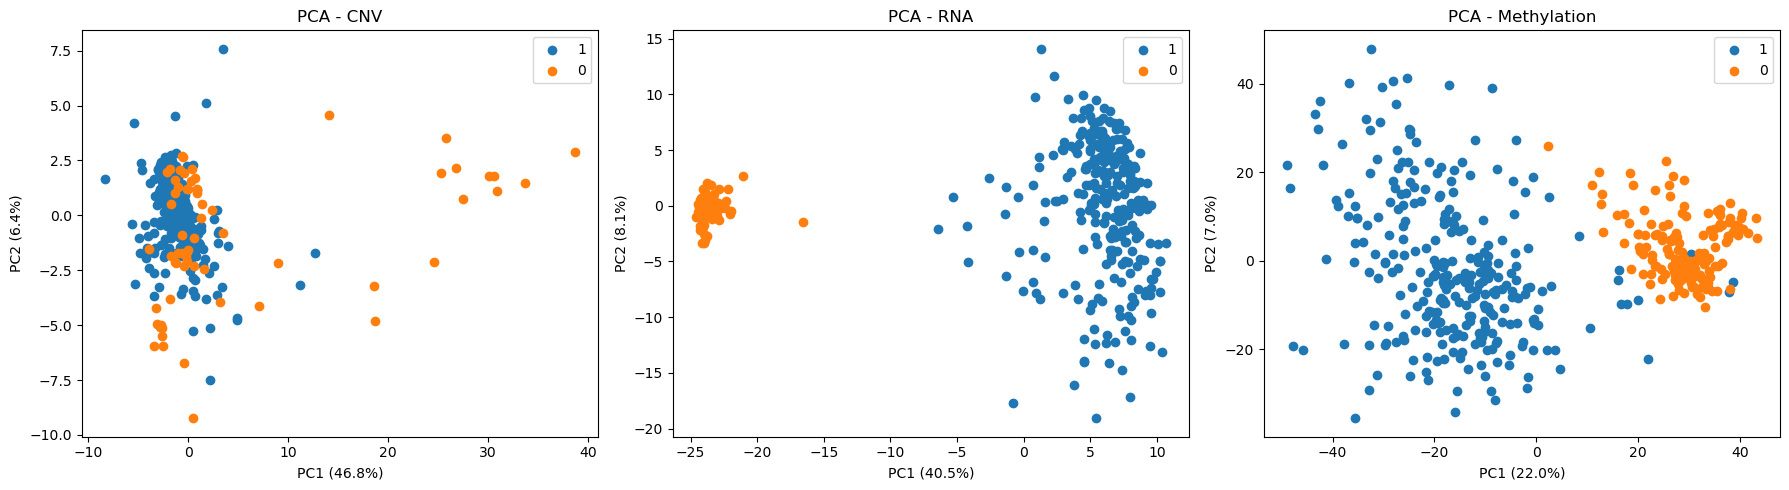

In [ ]:
# CNV
pca_cnv_model = PCA(n_components=2)
pca_cnv = pca_cnv_model.fit_transform(cnv.drop(columns="sample_id"))
var_cnv = pca_cnv_model.explained_variance_ratio_

# RNA
pca_rna_model = PCA(n_components=2)
pca_rna = pca_rna_model.fit_transform(rna.drop(columns="sample_id"))
var_rna = pca_rna_model.explained_variance_ratio_

# Methylation
pca_meth_model = PCA(n_components=2)
pca_meth = pca_meth_model.fit_transform(meth.drop(columns="sample_id"))
var_meth = pca_meth_model.explained_variance_ratio_

plt.figure(figsize=(18,5))

# CNV
plt.subplot(1,3,1)

for s in pca_df_cnv["status"].dropna().unique():
    tmp = pca_df_cnv[pca_df_cnv["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_cnv[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_cnv[1]*100:.1f}%)")
plt.title("PCA - CNV")
plt.legend()

# RNA
plt.subplot(1,3,2)
for s in pca_df_rna["status"].dropna().unique():
    tmp = pca_df_rna[pca_df_rna["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_rna[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_rna[1]*100:.1f}%)")
plt.title("PCA - RNA")
plt.legend()

# Methylation

plt.subplot(1,3,3)
for s in pca_df_meth["status"].dropna().unique():
    tmp = pca_df_meth[pca_df_meth["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_meth[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_meth[1]*100:.1f}%)")
plt.title("PCA - Methylation")
plt.legend()
plt.tight_layout()
plt.show()

In [130]:
# Differential CNV / Expression / Methylation

# Define function
def differential_analysis(labels, matrix, adjustment_method="bonferroni"):

    results = []

    # ensure numpy/pandas alignment
    labels = np.array(labels)

    for gene in matrix.columns:
        groups = np.unique(labels)
        group1 = matrix.loc[labels == groups[0], gene]
        group2 = matrix.loc[labels != groups[0], gene]
        stat, p = ranksums(group1, group2)
        diff_in_medians = np.median(group1) - np.median(group2)

        results.append((gene, stat, p, diff_in_medians))
    df = pd.DataFrame(results, columns=["gene", "stat", "p_value", "diff_in_medians"])

    # multiple testing correction (BH or others)
    reject, p_adj, _, _ = multipletests(df["p_value"], method=adjustment_method)
    df["p_adj"] = p_adj
    df["significant"] = reject
    return df.sort_values("p_adj")

In [142]:
# Differential gene expression
my_labels = metadata.loc[rna["sample_id"],"label"].values
my_genes = rna.drop(columns="sample_id")

gex_differential_analysis = differential_analysis(my_labels, my_genes)

significant_gex = gex_differential_analysis[gex_differential_analysis["p_adj"] < 0.05]
print("Number of significant transcripts {}".format(len(significant_gex)))

Number of significant transcripts 11441


In [143]:
# Differential copy number
my_labels = metadata.loc[cnv["sample_id"],"label"].values
my_cnv = cnv.drop(columns="sample_id")

cnv_differential_analysis = differential_analysis(my_labels, my_cnv)

significant_cnv = cnv_differential_analysis[cnv_differential_analysis["p_adj"] < 0.05]
print("Number of significant genes by CNV {}".format(len(significant_cnv)))

Number of significant genes by CNV 13830


In [145]:
# Differential methylation
my_labels = metadata.loc[meth["sample_id"],"label"].values
my_meth = meth.drop(columns="sample_id")

meth_differential_analysis = differential_analysis(my_labels, my_meth)

significant_cpgs = meth_differential_analysis[meth_differential_analysis["p_adj"] < 0.05]
print("Number of significant cpgs {}".format(len(significant_cpgs)))

Number of significant cpgs 230022


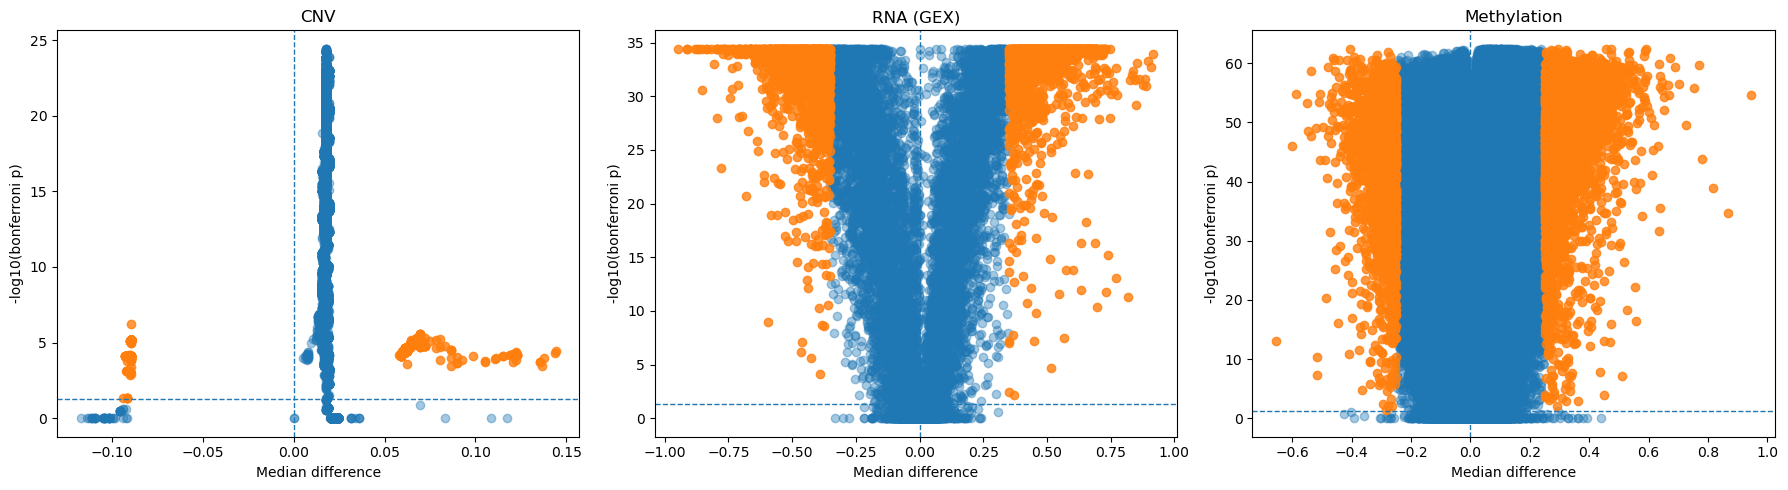

In [154]:
def volcano(ax, df, title, p_adj_th = 0.05, effect_size_th = 0.25):

    effect = df["diff_in_medians"]
    neg_log_p = -np.log10(df["p_adj"] + 1e-300)
    sig = (df["p_adj"] < p_adj_th) & (np.abs(df["diff_in_medians"]) > effect_size_th)

    ax.scatter(effect[~sig], neg_log_p[~sig], alpha=0.4)
    ax.scatter(effect[sig], neg_log_p[sig], alpha=0.8)

    ax.axhline(-np.log10(0.05), linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Median difference")
    ax.set_ylabel("-log10(bonferroni p)")


plt.figure(figsize=(18,5))

ax1 = plt.subplot(1,3,1)
volcano(ax1, cnv_differential_analysis, "CNV", p_adj_th = 0.05, effect_size_th = 0.05)

ax2 = plt.subplot(1,3,2)
volcano(ax2, gex_differential_analysis, "RNA (GEX)", p_adj_th = 0.05, effect_size_th = 0.35)

ax3 = plt.subplot(1,3,3)
volcano(ax3, meth_differential_analysis, "Methylation", p_adj_th = 0.05, effect_size_th = 0.25)

plt.tight_layout()
plt.show()